# LeetCode #283: Move Zeroes

https://leetcode.com/problems/move-zeroes/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n)$ | $O(n)$ |
| **Two Pointers (Write + Fill)** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Collect all non-zero elements into a new array, then copy them back followed by zeros. Correct, but allocates $O(n)$ auxiliary space for a problem that only requires rearranging elements already in the array.

### Optimal: Two Pointers (Write + Fill) ★
Use a write pointer k that starts at 0. Scan with a read pointer i: whenever a non-zero is found, write it to nums[k] and advance k. After the scan, zero-fill indices k through n−1. Two passes, no extra allocation.

**Why this is better than Brute Force:** The sorted-write-then-fill pattern eliminates the auxiliary array entirely. Every write either places a non-zero in its correct relative position or overwrites the tail with zeros — no element is ever copied to external storage.

**Constraints:**
* 1 ≤ nums.length ≤ 10⁴
* −2³¹ ≤ nums[i] ≤ 2³¹ − 1

## Solutions

### C#

In [ ]:
public class Solution {
    public void MoveZeroes(int[] nums) {
        int k = 0;
        // Write all non-zeros to the front, preserving relative order
        for (int i = 0; i < nums.Length; i++)
            if (nums[i] != 0) nums[k++] = nums[i];
        // Zero-fill the tail
        while (k < nums.Length) nums[k++] = 0;
    }
}

### Python

In [ ]:
class Solution:
    def moveZeroes(self, nums: List[int]) -> None:
        k = 0
        # Write all non-zeros to the front, preserving relative order
        for num in nums:
            if num != 0:
                nums[k] = num
                k += 1
        # Zero-fill the tail
        while k < len(nums):
            nums[k] = 0
            k += 1

### Go

In [ ]:
func moveZeroes(nums []int) {
    k := 0
    // Write all non-zeros to the front, preserving relative order
    for _, num := range nums {
        if num != 0 {
            nums[k] = num
            k++
        }
    }
    // Zero-fill the tail
    for k < len(nums) {
        nums[k] = 0
        k++
    }
}

### Rust

In [ ]:
pub fn move_zeroes(nums: &mut Vec<i32>) {
    let mut k = 0usize;
    // Write all non-zeros to the front, preserving relative order
    for i in 0..nums.len() {
        if nums[i] != 0 {
            nums[k] = nums[i];
            k += 1;
        }
    }
    // Zero-fill the tail
    while k < nums.len() {
        nums[k] = 0;
        k += 1;
    }
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [0, 1, 0, 3, 12]
Pass 1 (write non-zeros): i=0 zero skip; i=1 nums[0]=1, k=1; i=2 zero skip; i=3 nums[1]=3, k=2; i=4 nums[2]=12, k=3. Pass 2 (fill): nums[3]=0, nums[4]=0. Result: **[1, 3, 12, 0, 0]**.

**2. Slightly Complex — multiple scattered zeros**
**Input:** nums = [0, 0, 1, 0, 2, 0, 3]
Pass 1: only i=2,4,6 trigger writes → nums[0]=1, nums[1]=2, nums[2]=3, k=3. Pass 2: nums[3..6] = 0. Four zeros collapse to the tail in the fill phase; relative order of 1, 2, 3 preserved. Result: **[1, 2, 3, 0, 0, 0, 0]**.

**3. Edge Case: Time Factor — all zeros**
**Input:** nums = [0, 0, 0, 0]
Pass 1: every element is 0 → k stays at 0, zero writes occur. Pass 2: fills all 4 positions with 0 — the array is unchanged. This is the worst case for the fill pass: $O(n)$ zero-writes, $O(n)$ comparisons in pass 1, zero useful non-zero writes. Brute Force with an extra array also visits every element twice. Result: **[0, 0, 0, 0]**.

**4. Edge Case: Space Factor — no zeros**
**Input:** nums = [1, 2, 3, 4, 5]
Pass 1: every element is non-zero → nums[k]=nums[i] for k==i (self-write), k reaches n. Pass 2: k==n immediately, zero fill loop never executes. Extra space: $O(1)$ — two integers (k, i) only. Brute Force would allocate a 5-element array that is never needed here. Result: **[1, 2, 3, 4, 5]** (unchanged).

**5. Almost-Impossible but Plausible — single zero**
**Input:** nums = [0]
Pass 1: nums[0]==0 → skip, k stays 0. Pass 2: k=0 < 1 → nums[0]=0, k=1. Loop exits. Array unchanged. Alternatively [5]: Pass 1 writes nums[0]=5, k=1. Pass 2: k==1==length, fill loop skipped. Both single-element cases exit cleanly. Result: **[0]** or **[5]** respectively.

## Infographic

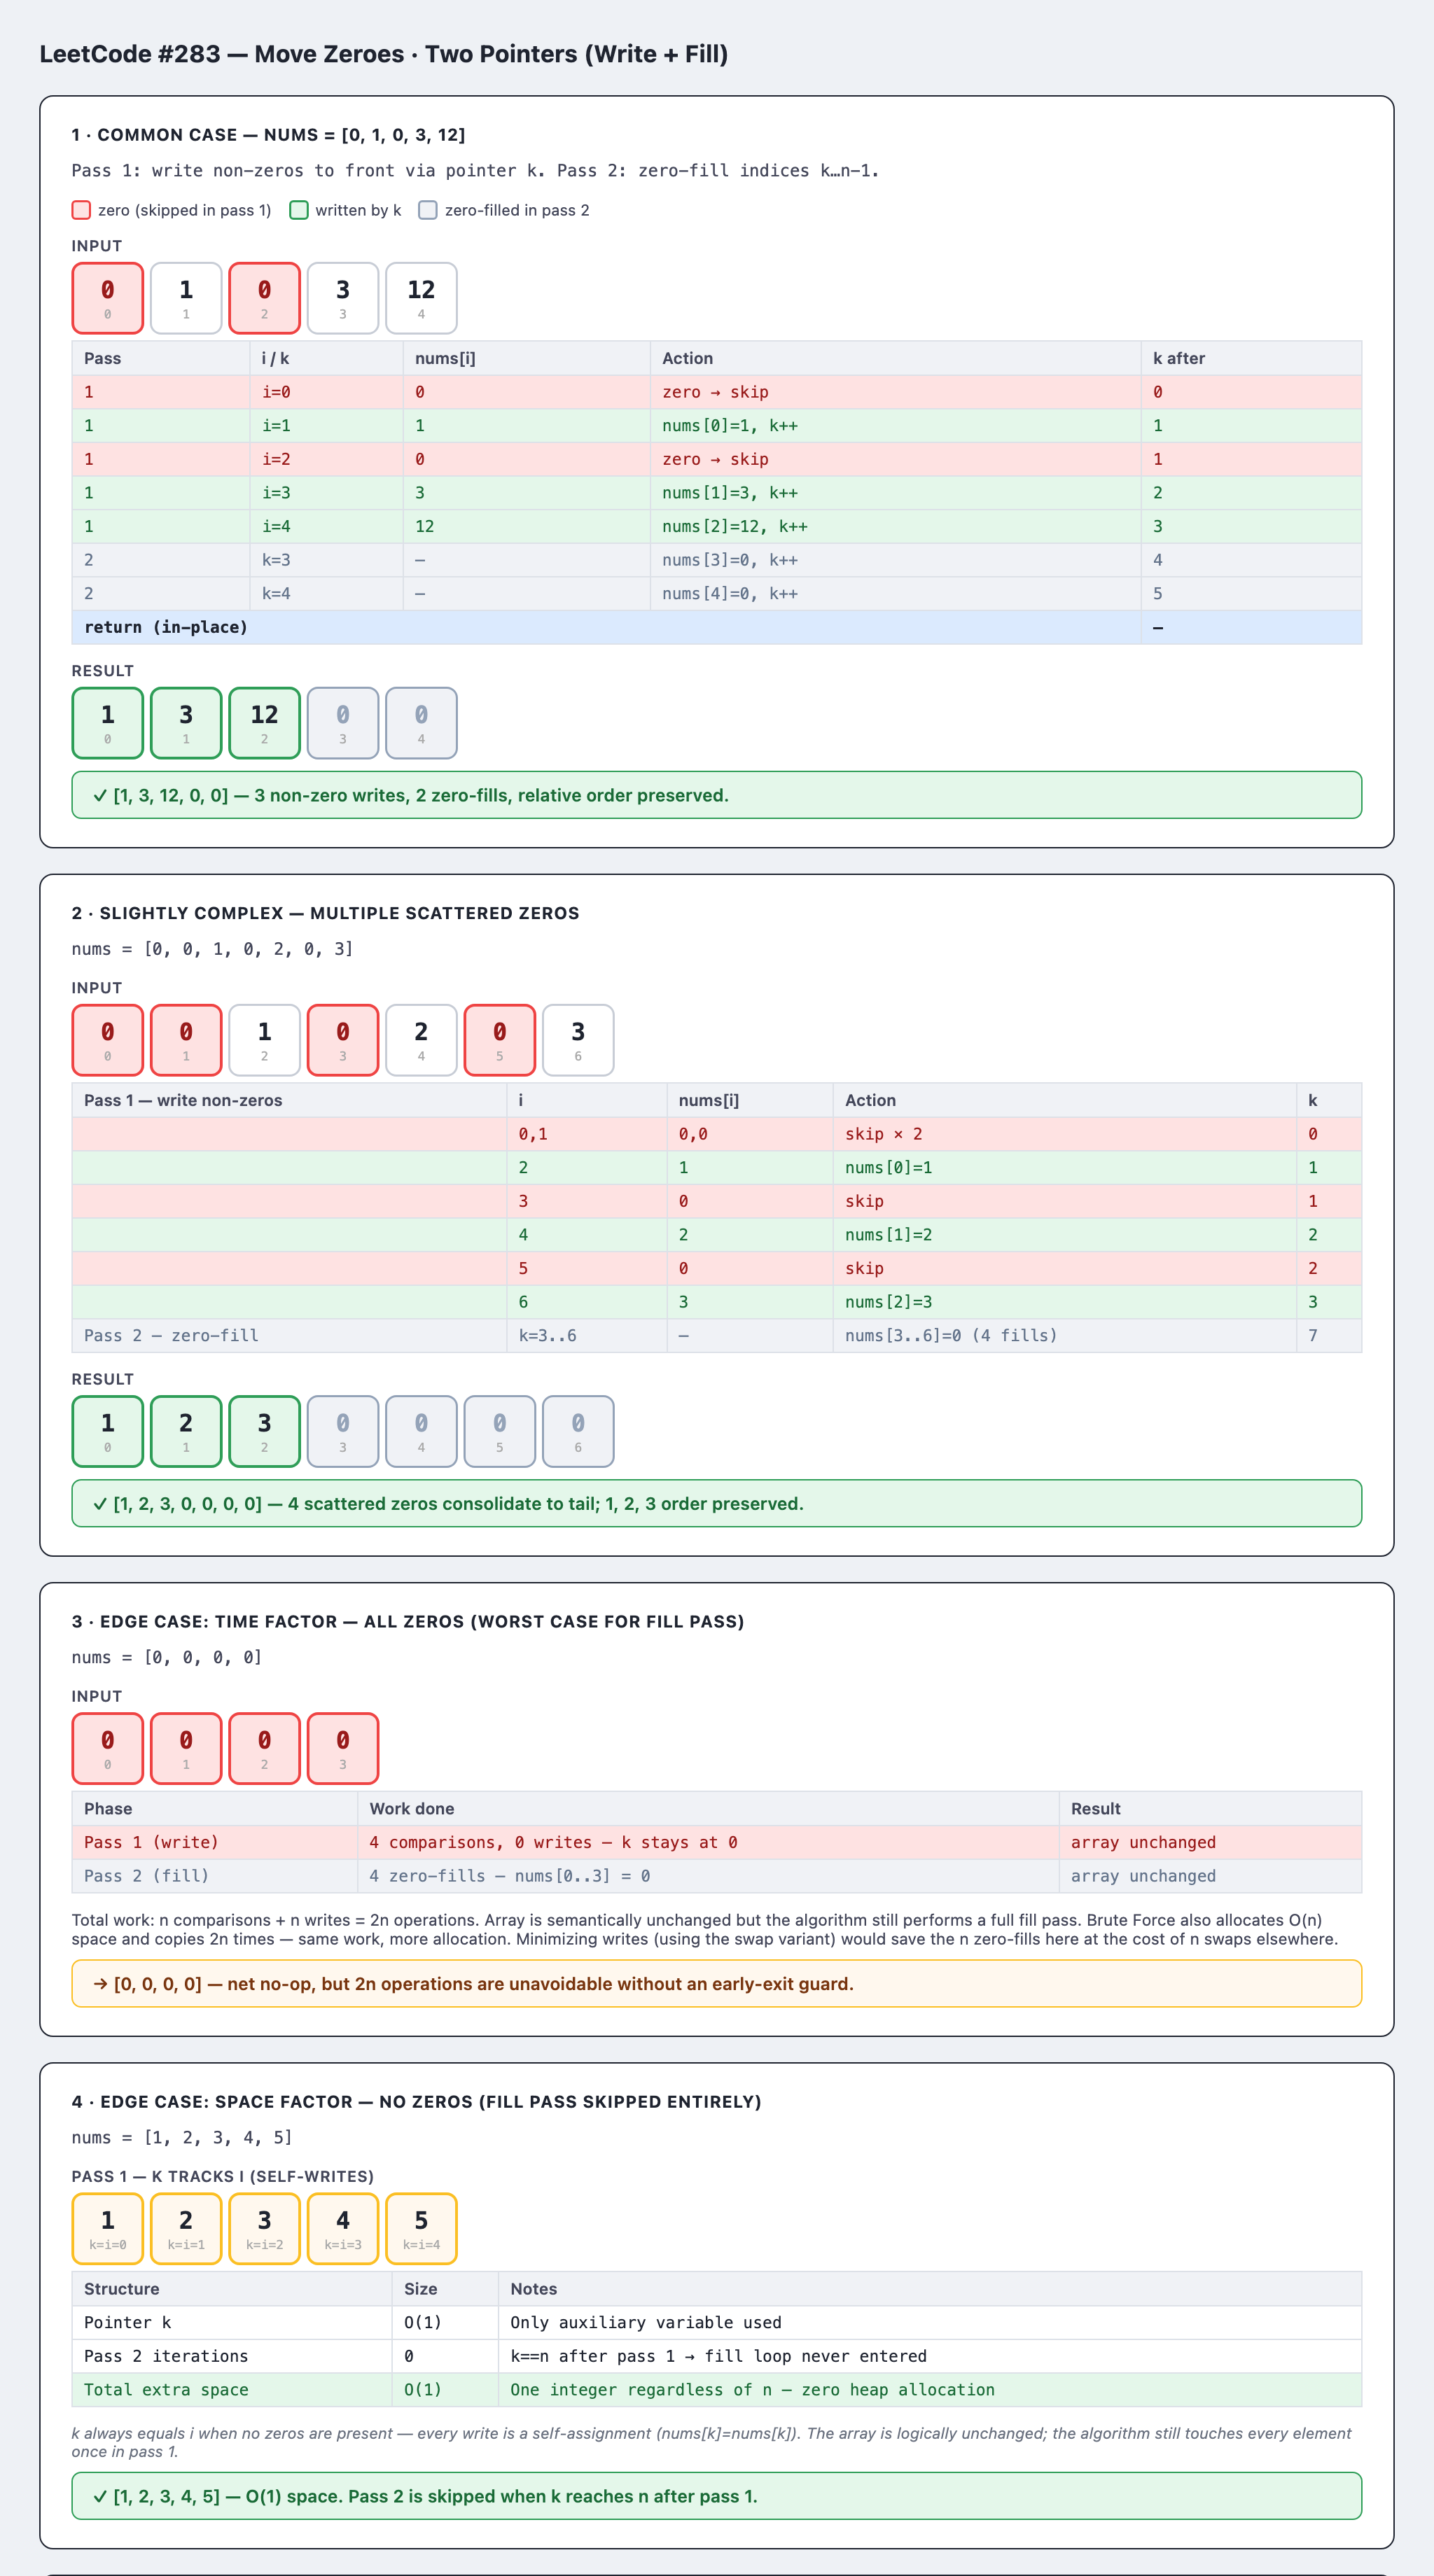